# Scaling experiments

Measure how the Stegosaurus worker pool behaves under load across GPU and CPU deployments.

**GPU deployments**: VRAM is the bottleneck. Each worker holds an independent model copy; the GPU kernel scheduler handles concurrency internally.

**CPU-only deployments**: PyTorch inference saturates all available cores per forward pass. The `WorkerManager` caps `max_workers` at `cpu_count` and distributes cores evenly across alive workers via a shared `threads_per_worker` value.

## Structure

1. **Set-up**: imports, configuration, data restore
2. **Single-worker performance**: GPU and CPU baselines, side-by-side comparison
3. **GPU scaling**: effect of adding workers; dynamic auto-scaling trace
4. **CPU scaling**: thread allocation mechanism; effect of adding workers on throughput and latency

## 1. Set-up

### 1.1. Imports

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd

from helpers import (
    burst, FIGURES_DIR, load_data, run_scaling_trace,
    run_sweep_step, save_data, summarize
)

### 1.2. Configuration

Edit `APP_URL` to point at a running Stegosaurus instance.

In [2]:
APP_URL = 'http://localhost:8080'

# Payload used for every encode request
PROMPT = 'Write a short story about a lighthouse keeper.'
MESSAGE = 'hello'

# Set to True to run the experiment live and save results.
# Set to False to load previously saved data and regenerate plots only.
RUN_GPU = False
RUN_CPU = False

# Dynamic scaling trace parameters (shared between sections 3.2 and 4.3)
SAMPLE_INTERVAL_S = 1.0   # seconds between worker-count samples
QUIESCE_STABLE_S  = 10    # stop once count is stable for this long
QUIESCE_TIMEOUT_S = 180   # give up waiting after this many seconds

### 1.3. Data persistence

All experiment results are saved to `notebooks/data/scaling_data.json` as a single JSON object with one key per experiment. Each measurement cell checks the `RUN_GPU` / `RUN_CPU` flag: if `True` it runs live and saves; if `False` it loads existing data. The restore cell below pre-loads everything so plots regenerate after a kernel restart without re-running any experiments.

In [3]:
# Restore all saved experiment data from scaling_data.json.
# Run this after a kernel restart to regenerate plots without re-running experiments.

# Initialise all data variables so plot cells don't raise NameError when data
# has not been collected yet.
df_baseline = df_cpu_baseline = df_msg_sweep_gpu = df_msg_sweep_cpu = None
df_sweep = df_thread_sweep = df_throughput_sweep = None
samples = burst_wall = None
cpu_samples = cpu_burst_wall = None

_d = load_data('scaling_data.json') or {}

if _d.get('baseline_rows'):
    df_baseline = pd.DataFrame(_d['baseline_rows'])
    print(f'Loaded GPU baseline:           {len(df_baseline)} rows')

if _d.get('cpu_baseline_rows'):
    df_cpu_baseline = pd.DataFrame(_d['cpu_baseline_rows'])
    print(f'Loaded CPU baseline:           {len(df_cpu_baseline)} rows')

if _d.get('message_size_rows_gpu'):
    df_msg_sweep_gpu = pd.DataFrame(_d['message_size_rows_gpu'])
    print(f'Loaded GPU message sweep:      {len(df_msg_sweep_gpu)} rows')

if _d.get('message_size_rows_cpu'):
    df_msg_sweep_cpu = pd.DataFrame(_d['message_size_rows_cpu'])
    print(f'Loaded CPU message sweep:      {len(df_msg_sweep_cpu)} rows')

if _d.get('sweep_rows'):
    df_sweep = pd.DataFrame(_d['sweep_rows']).sort_values('max_workers')
    print(f'Loaded worker sweep:           {len(df_sweep)} rows')

if _d.get('scaling_trace'):
    samples = [tuple(s) for s in _d['scaling_trace']['samples']]
    burst_wall = _d['scaling_trace']['burst_wall']
    print(f'Loaded GPU scaling trace:      {len(samples)} samples')

if _d.get('thread_sweep_rows'):
    df_thread_sweep = (
        pd.DataFrame(_d['thread_sweep_rows'])
        .sort_values('n_workers')
        .reset_index(drop=True)
    )
    print(f'Loaded thread sweep:           {len(df_thread_sweep)} rows')

if _d.get('throughput_sweep_rows'):
    df_throughput_sweep = (
        pd.DataFrame(_d['throughput_sweep_rows'])
        .sort_values('n_workers')
        .reset_index(drop=True)
    )
    print(f'Loaded throughput sweep:       {len(df_throughput_sweep)} rows')

if _d.get('cpu_scaling_trace'):
    cpu_samples = [tuple(s) for s in _d['cpu_scaling_trace']['samples']]
    cpu_burst_wall = _d['cpu_scaling_trace']['burst_wall']
    print(f'Loaded CPU scaling trace:      {len(cpu_samples)} samples')

Loaded CPU baseline:           4 rows
Loaded CPU message sweep:      7 rows
Loaded thread sweep:           8 rows


## 2. Single-worker performance

Establish the baseline for a single worker before adding more. This section runs the same concurrency sweep on both GPU and CPU so the two can be compared directly.

### 2.1. GPU single-worker baseline

Start the app on a **GPU** instance with `MAX_WORKERS=1 MIN_WORKERS=1`, then run the cell below. Each concurrency level fires `BASELINE_REQUESTS_PER_LEVEL` parallel requests.

In [4]:
BASELINE_CONCURRENCY_LEVELS = [1, 2, 4, 8]
BASELINE_REQUESTS_PER_LEVEL = 10

_d = load_data('scaling_data.json') or {}

if not RUN_GPU:
    if _d.get('baseline_rows'):
        df_baseline = pd.DataFrame(_d['baseline_rows'])
        print(f'Loaded {len(df_baseline)} rows from scaling_data.json')
    else:
        print('RUN_GPU=False and no saved data found for GPU baseline.')
        df_baseline = None
else:
    baseline_rows = []
    for concurrency in BASELINE_CONCURRENCY_LEVELS:
        times, wall = burst(APP_URL, PROMPT, MESSAGE, BASELINE_REQUESTS_PER_LEVEL, concurrency)
        stats = summarize(times, wall)
        baseline_rows.append({'concurrency': concurrency, **stats})

    _d['baseline_rows'] = baseline_rows
    save_data('scaling_data.json', _d)
    df_baseline = pd.DataFrame(baseline_rows)


RUN_GPU=False and no saved data found for GPU baseline.


In [5]:
if df_baseline is None:
    print('No GPU baseline data. Run the measurement cell above.')
else:
    x = df_baseline['concurrency']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    ax1.set_title('Single worker: latency vs concurrency')
    ax1.plot(x, df_baseline['median_s'], marker='o', label='median')
    ax1.plot(x, df_baseline['p95_s'], marker='o', linestyle='--', label='p95')
    ax1.set_xlabel('Concurrent callers')
    ax1.set_ylabel('Latency (s)')
    ax1.legend()

    ax2.set_title('Single worker: throughput vs concurrency')
    ax2.plot(x, df_baseline['throughput_rps'], marker='o', color='seagreen')
    ax2.set_xlabel('Concurrent callers')
    ax2.set_ylabel('Throughput (req/s)')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-2.1-GPU-single-worker.jpg', dpi=300, bbox_inches='tight')
    plt.show()

No GPU baseline data. Run the measurement cell above.


### 2.2. CPU single-worker baseline

Start the app with `MAX_WORKERS=1 MIN_WORKERS=1` on a **CPU-only** instance, then run the cell below.

In [6]:
CPU_BASELINE_CONCURRENCY_LEVELS = [1, 2, 4, 8]
CPU_BASELINE_REQUESTS_PER_LEVEL = 10

_d = load_data('scaling_data.json') or {}

if not RUN_CPU:
    if _d.get('cpu_baseline_rows'):
        df_cpu_baseline = pd.DataFrame(_d['cpu_baseline_rows'])
        print(f'Loaded {len(df_cpu_baseline)} rows from scaling_data.json')
    else:
        print('RUN_CPU=False and no saved data found for CPU baseline.')
        df_cpu_baseline = None
else:
    cpu_baseline_rows = []
    for concurrency in CPU_BASELINE_CONCURRENCY_LEVELS:
        times, wall = burst(APP_URL, PROMPT, MESSAGE, CPU_BASELINE_REQUESTS_PER_LEVEL, concurrency)
        stats = summarize(times, wall)
        cpu_baseline_rows.append({'concurrency': concurrency, **stats})

    _d['cpu_baseline_rows'] = cpu_baseline_rows
    save_data('scaling_data.json', _d)
    df_cpu_baseline = pd.DataFrame(cpu_baseline_rows)

df_cpu_baseline  # None if no data


Loaded 4 rows from scaling_data.json


,concurrency,n,min_s,median_s,p95_s,max_s,throughput_rps
0,1,10,18.86,19.36,19.91,19.91,0.05
1,2,10,19.70,20.01,20.71,20.71,0.10
2,4,10,19.81,23.15,23.68,23.68,0.15
3,8,10,20.22,35.08,35.53,35.53,0.18


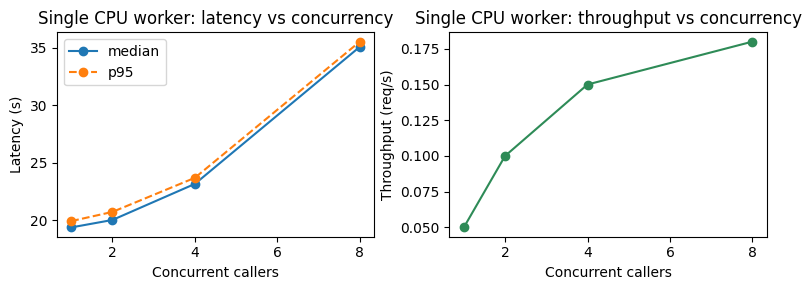

In [7]:
if df_cpu_baseline is None:
    print('No CPU baseline data. Run the measurement cell above.')
else:
    x = df_cpu_baseline['concurrency']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    ax1.set_title('Single CPU worker: latency vs concurrency')
    ax1.plot(x, df_cpu_baseline['median_s'], marker='o', label='median')
    ax1.plot(x, df_cpu_baseline['p95_s'], marker='o', linestyle='--', label='p95')
    ax1.set_xlabel('Concurrent callers')
    ax1.set_ylabel('Latency (s)')
    ax1.legend()

    ax2.set_title('Single CPU worker: throughput vs concurrency')
    ax2.plot(x, df_cpu_baseline['throughput_rps'], marker='o', color='seagreen')
    ax2.set_xlabel('Concurrent callers')
    ax2.set_ylabel('Throughput (req/s)')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-2.2-CPU-single-worker.jpg', dpi=300, bbox_inches='tight')
    plt.show()

### 2.3. GPU vs CPU comparison

In [8]:
if df_baseline is not None and df_cpu_baseline is not None:
    x = df_baseline['concurrency']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    fig.suptitle('GPU vs CPU: single-worker performance', y=1.02)

    ax1.set_title('Latency vs concurrency')
    ax1.plot(x, df_baseline['median_s'],     marker='o', label='GPU median',  color='steelblue')
    ax1.plot(x, df_baseline['p95_s'],        marker='o', linestyle='--', label='GPU p95', color='steelblue', alpha=0.5)
    ax1.plot(x, df_cpu_baseline['median_s'], marker='s', label='CPU median',  color='tomato')
    ax1.plot(x, df_cpu_baseline['p95_s'],    marker='s', linestyle='--', label='CPU p95', color='tomato', alpha=0.5)
    ax1.set_xlabel('Concurrent callers')
    ax1.set_ylabel('Latency (s)')
    ax1.legend()

    ax2.set_title('Throughput vs concurrency')
    ax2.plot(x, df_baseline['throughput_rps'],     marker='o', label='GPU', color='steelblue')
    ax2.plot(x, df_cpu_baseline['throughput_rps'], marker='s', label='CPU', color='tomato')
    ax2.set_xlabel('Concurrent callers')
    ax2.set_ylabel('Throughput (req/s)')
    ax2.legend()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-2.3-GPU-vs-CPU.jpg', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('Run both GPU and CPU baseline cells before plotting the comparison.')

Run both GPU and CPU baseline cells before plotting the comparison.


### 2.4. Message size sweep

Longer hidden messages require more tokens to encode, so latency and throughput are expected to degrade as message length grows. This experiment sweeps `MSG_SWEEP_LENGTHS` with a single worker at `concurrency=1` on both GPU and CPU, isolating the cost of message length from any parallelism effects.

Start the app with `MAX_WORKERS=1 MIN_WORKERS=1` on the target instance. Toggle `RUN_GPU` / `RUN_CPU` to run each platform, then run the measurement cell followed by the plot cell.

In [9]:
MSG_SWEEP_LENGTHS = [1, 2, 4, 8, 16, 32, 64]   # message lengths in characters
MSG_SWEEP_REQUESTS = 10                         # requests per length (concurrency=1)

_d = load_data('scaling_data.json') or {}

# --- GPU ---
if not RUN_GPU:
    if _d.get('message_size_rows_gpu'):
        df_msg_sweep_gpu = pd.DataFrame(_d['message_size_rows_gpu'])
        print(f'Loaded {len(df_msg_sweep_gpu)} GPU rows from scaling_data.json')
    else:
        print('RUN_GPU=False and no saved data found for GPU message-size sweep.')
        df_msg_sweep_gpu = None
else:
    msg_rows_gpu = []
    for length in MSG_SWEEP_LENGTHS:
        msg = 'a' * length
        times, wall = burst(APP_URL, PROMPT, msg, MSG_SWEEP_REQUESTS, n_workers=1)
        stats = summarize(times, wall)
        msg_rows_gpu.append({'message_len': length, **stats})
    _d['message_size_rows_gpu'] = msg_rows_gpu
    save_data('scaling_data.json', _d)
    df_msg_sweep_gpu = pd.DataFrame(msg_rows_gpu)

# --- CPU ---
if not RUN_CPU:
    if _d.get('message_size_rows_cpu'):
        df_msg_sweep_cpu = pd.DataFrame(_d['message_size_rows_cpu'])
        print(f'Loaded {len(df_msg_sweep_cpu)} CPU rows from scaling_data.json')
    else:
        print('RUN_CPU=False and no saved data found for CPU message-size sweep.')
        df_msg_sweep_cpu = None
else:
    msg_rows_cpu = []
    for length in MSG_SWEEP_LENGTHS:
        msg = 'a' * length
        times, wall = burst(APP_URL, PROMPT, msg, MSG_SWEEP_REQUESTS, n_workers=1)
        stats = summarize(times, wall)
        msg_rows_cpu.append({'message_len': length, **stats})
    _d['message_size_rows_cpu'] = msg_rows_cpu
    save_data('scaling_data.json', _d)
    df_msg_sweep_cpu = pd.DataFrame(msg_rows_cpu)


RUN_GPU=False and no saved data found for GPU message-size sweep.
Loaded 7 CPU rows from scaling_data.json


In [10]:
if df_msg_sweep_gpu is not None and df_msg_sweep_cpu is not None:

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
    fig.suptitle('Throughput and latency vs message length (single worker)', y=1.02)

    ax1.set_title('Latency vs message length')

    ax1.plot(
        df_msg_sweep_gpu['message_len'], df_msg_sweep_gpu['median_s'],
        marker='o', label='GPU median', color='steelblue'
    )
    ax1.plot(
        df_msg_sweep_gpu['message_len'], df_msg_sweep_gpu['p95_s'],
        marker='o', linestyle='--', label='GPU p95', color='steelblue', alpha=0.5
    )
    ax1.plot(
        df_msg_sweep_cpu['message_len'], df_msg_sweep_cpu['median_s'],
        marker='s', label='CPU median', color='tomato'
    )
    ax1.plot(
        df_msg_sweep_cpu['message_len'], df_msg_sweep_cpu['p95_s'],
        marker='s', linestyle='--', label='CPU p95', color='tomato', alpha=0.5
    )
    ax1.set_xlabel('Message length (chars)')
    ax1.set_ylabel('Latency (s)')
    ax1.legend()

    ax2.set_title('Throughput vs message length')
    ax2.plot(
        df_msg_sweep_gpu['message_len'], df_msg_sweep_gpu['throughput_rps'],
        marker='o', label='GPU', color='steelblue'
    )
    ax2.plot(
        df_msg_sweep_cpu['message_len'], df_msg_sweep_cpu['throughput_rps'],
        marker='s', label='CPU', color='tomato'
    )
    ax2.set_xlabel('Message length (chars)')
    ax2.set_ylabel('Throughput (req/s)')
    ax2.legend()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-2.4-message-size-sweep.jpg', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print('No message sweep data. Run the measurement cell above.')

No message sweep data. Run the measurement cell above.


## 3. GPU scaling

Workers are independent; each holds its own model copy in VRAM. Adding workers increases parallelism without any per-worker cost.

### 3.1 Effect of adding workers

For each value in `SWEEP_MAX_WORKERS`:
1. Restart the app with `MAX_WORKERS=<n> MIN_WORKERS=<n>` (pre-warmed so the pool is ready).
2. Set `N_WORKERS_THIS_RUN = <n>` in the cell below.
3. Run the measurement cell.
4. Repeat for the next value.

In [11]:
SWEEP_CONCURRENCY = 8             # fixed concurrent callers
SWEEP_REQUESTS = 20               # requests per max_workers setting
SWEEP_MAX_WORKERS = [1, 2, 4, 8]  # restart app between each

# Set this to match the MAX_WORKERS value the app was started with, then run.
# Re-run with a different value after restarting the app.
N_WORKERS_THIS_RUN = 8

df_sweep = run_sweep_step(
    'sweep_rows', RUN_GPU,
    APP_URL, PROMPT, MESSAGE,
    SWEEP_REQUESTS, SWEEP_CONCURRENCY,
    extra_fields={'max_workers': N_WORKERS_THIS_RUN},
    sort_by='max_workers',
)

df_sweep

run_flag=False and no saved data found for "sweep_rows".


#### 3.1.1 Per-worker throughput

`throughput_rps / max_workers`: should stay flat on GPU because each worker is fully independent.

In [12]:
if df_sweep is None:
    print('No worker sweep data. Run the measurement cell above.')
else:
    x = df_sweep['max_workers']

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(f'Per-worker throughput (concurrency={SWEEP_CONCURRENCY})')
    ax.bar(x.astype(str), df_sweep['throughput_rps'] / df_sweep['max_workers'],
           color='steelblue', alpha=0.8)
    ax.set_xlabel('max_workers')
    ax.set_ylabel('Throughput per worker (req/s)')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-3.1.1-per-worker-throughput.jpg', dpi=300, bbox_inches='tight')
    plt.show()

No worker sweep data. Run the measurement cell above.


#### 3.1.2 Total throughput vs worker count

Should scale linearly with workers, reflecting parallel independent GPU workers.

In [13]:
if df_sweep is None:
    print('No worker sweep data. Run the measurement cell above.')
else:
    x = df_sweep['max_workers']

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(f'Total throughput (concurrency={SWEEP_CONCURRENCY})')
    ax.bar(x.astype(str), df_sweep['throughput_rps'],
           color='steelblue', alpha=0.8)
    ax.set_xlabel('max_workers')
    ax.set_ylabel('Throughput (req/s)')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-3.1.2-total-throughput.jpg', dpi=300, bbox_inches='tight')
    plt.show()

No worker sweep data. Run the measurement cell above.


#### 3.1.3 Latency vs worker count

More workers shrink the queue so user-facing latency falls as the pool grows.

In [14]:
if df_sweep is None:
    print('No worker sweep data. Run the measurement cell above.')
else:
    x = df_sweep['max_workers']

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(f'Latency vs worker count (concurrency={SWEEP_CONCURRENCY})')
    ax.plot(x, df_sweep['median_s'], marker='o', label='median')
    ax.plot(x, df_sweep['p95_s'], marker='s', linestyle='--', label='p95')
    ax.set_xlabel('max_workers')
    ax.set_ylabel('Latency (s)')
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-3.1.3-latency-vs-workers.jpg', dpi=300, bbox_inches='tight')
    plt.show()

No worker sweep data. Run the measurement cell above.


### 3.2 Dynamic scaling trace

Start the app with `MIN_WORKERS=1 MAX_WORKERS=4`. The cell below:
1. Polls `pgrep` in a background thread to count live worker processes.
2. Fires a burst of requests.
3. Keeps sampling until the pool quiesces back to `MIN_WORKERS`.

In [15]:
BURST_CONCURRENCY = 8   # concurrent callers during the burst
BURST_REQUESTS = 30     # total requests in the burst

_d = load_data('scaling_data.json') or {}

if not RUN_GPU:
    if _d.get('scaling_trace'):
        samples = [tuple(s) for s in _d['scaling_trace']['samples']]
        burst_wall = _d['scaling_trace']['burst_wall']
        print(f'Loaded {len(samples)} samples from scaling_data.json')
    else:
        print('RUN_GPU=False and no saved data found for scaling trace.')
        samples = burst_wall = None
else:
    samples, burst_wall = run_scaling_trace(
        APP_URL, PROMPT, MESSAGE, BURST_REQUESTS, BURST_CONCURRENCY,
        sample_interval_s=SAMPLE_INTERVAL_S,
        quiesce_stable_s=QUIESCE_STABLE_S,
        quiesce_timeout_s=QUIESCE_TIMEOUT_S,
    )
    _d['scaling_trace'] = {
        'samples': [list(s) for s in samples],
        'burst_wall': burst_wall,
    }
    save_data('scaling_data.json', _d)


RUN_GPU=False and no saved data found for scaling trace.


#### Worker count over time

In [16]:
if samples is None:
    print('No GPU scaling trace data. Run the measurement cell above.')
else:
    ts, counts = zip(*samples)

    # Approximate burst window: t=3s to t=3+burst_wall
    burst_start_t = 3.0
    burst_end_t = burst_start_t + burst_wall

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title('Dynamic scaling trace')
    ax.step(ts, counts, where='post', linewidth=2, label='worker count')
    ax.axvspan(burst_start_t, burst_end_t, alpha=0.15, color='grey', label='burst window')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Worker processes')
    ax.yaxis.get_major_locator().set_params(integer=True)
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-3.2-scaling-trace.jpg', dpi=300, bbox_inches='tight')
    plt.show()

No GPU scaling trace data. Run the measurement cell above.


## 4. CPU scaling

On CPU, PyTorch inference saturates all available cores per forward pass. Over-provisioning workers causes CPU thrashing.

The `WorkerManager` addresses this two ways:
1. `max_workers` is capped at `cpu_count` (via `os.sched_getaffinity`).
2. A shared `threads_per_worker = cpu_count // alive_workers` is updated on every scale event; each worker calls `torch.set_num_threads()` before every job.

### 4.1 Thread-per-worker mechanism

Computed from `os.sched_getaffinity(0)`; no running app required. Shows the `threads_per_worker` value for every possible pool size and confirms that `threads × workers` never exceeds `cpu_count`.

In [17]:
try:
    cpu_count = len(os.sched_getaffinity(0))

except AttributeError:
    cpu_count = os.cpu_count() or 1

thread_rows = []

for n_workers in range(1, cpu_count + 1):
    
    tpw = max(1, cpu_count // n_workers)

    thread_rows.append({
        'workers': n_workers,
        'threads_per_worker': tpw,
        'total_threads_in_use': tpw * n_workers,
        'idle_cores': max(0, cpu_count - tpw * n_workers),
    })

df_threads = pd.DataFrame(thread_rows)
print(f'cpu_count = {cpu_count}')

cpu_count = 24


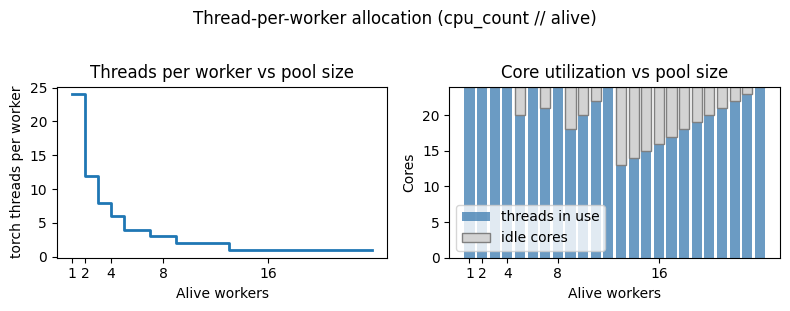

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

plt.suptitle('Thread-per-worker allocation (cpu_count // alive)', y=1.02)

x = df_threads['workers']

# Only label tick marks at powers of 2 to avoid crowding on large machines.
pow2_vals = [v for v in x if v == 1 or (v & (v - 1)) == 0]
pow2_positions = [i for i, v in enumerate(x) if v in set(pow2_vals)]

ax1.set_title('Threads per worker vs pool size')
ax1.step(
    x, df_threads['threads_per_worker'],
    where='post', linewidth=2
)
ax1.set_xlabel('Alive workers')
ax1.set_ylabel('torch threads per worker')
ax1.set_xticks(pow2_vals)

ax2.set_title('Core utilization vs pool size')
ax2.bar(
    x.astype(str), df_threads['total_threads_in_use'],
    label='threads in use', color='steelblue', alpha=0.8
)
ax2.bar(
    x.astype(str), df_threads['idle_cores'],
    bottom=df_threads['total_threads_in_use'],
    label='idle cores', color='lightgrey', edgecolor='grey'
)
ax2.set_xticks(pow2_positions)
ax2.set_xticklabels([str(v) for v in pow2_vals])
ax2.set_xlabel('Alive workers')
ax2.set_ylabel('Cores')
ax2.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / '03-4.1-thread-allocation.jpg', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Effect of adding workers

#### 4.2.1. Per-worker throughput

For each `N` in `THREAD_SWEEP_WORKERS`:
1. Restart the app: `MAX_WORKERS=N MIN_WORKERS=N python demo/app.py`.
2. Set `N_WORKERS_THIS_RUN = N` in the cell below and run it.
3. Repeat for the next value.

With `concurrency=1`, only one worker is active at a time, isolating the effect of `torch.set_num_threads(cpu_count // N)` on individual worker performance.

In [19]:
THREAD_SWEEP_WORKERS = [1, 2, 3, 4, 6, 8, 12, 24]   # adjust to <= your cpu_count
THREAD_SWEEP_REQUESTS = 10                          # requests per worker count (concurrency=1)

# Set this to match MAX_WORKERS=MIN_WORKERS the app was started with, then run.
N_WORKERS_THIS_RUN = 24

# concurrency=1: sequential requests so each run measures one worker in isolation.
df_thread_sweep = run_sweep_step(
    'thread_sweep_rows', RUN_CPU,
    APP_URL, PROMPT, MESSAGE,
    THREAD_SWEEP_REQUESTS, 1,
    extra_fields={
        'n_workers': N_WORKERS_THIS_RUN,
        'threads_per_worker': max(1, cpu_count // N_WORKERS_THIS_RUN),
    },
    sort_by='n_workers',
)

df_thread_sweep

Loaded 8 rows from scaling_data.json


,n_workers,threads_per_worker,n,min_s,median_s,p95_s,max_s,throughput_rps
0,1,24,10,30.17,33.13,40.18,40.18,0.03
1,2,12,10,9.00,9.22,9.99,9.99,0.11
2,3,8,10,8.69,8.86,9.59,9.59,0.11
3,4,6,10,8.74,8.94,9.59,9.59,0.11
4,6,4,10,9.54,9.64,10.44,10.44,0.10
5,8,3,10,10.34,10.49,11.25,11.25,0.09
6,12,2,10,12.14,12.42,12.84,12.84,0.08
7,24,1,10,18.56,18.75,19.55,19.55,0.05


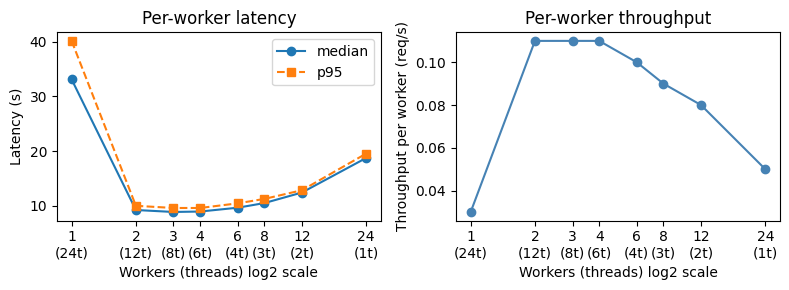

In [30]:
if df_thread_sweep is None or len(df_thread_sweep) < 2:
    print('Run the cell above for at least 2 worker counts before plotting.')

else:
    x = df_thread_sweep['n_workers']
    x_labels = [
        f'{row.n_workers}\n({row.threads_per_worker}t)'
        for row in df_thread_sweep.itertuples()
    ]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

    for ax in (ax1, ax2):
        ax.set_xscale('log', base=2)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels)
        ax.set_xlabel('Workers (threads) log2 scale')

    ax1.set_title('Per-worker latency')
    ax1.plot(x, df_thread_sweep['median_s'], marker='o', label='median')
    ax1.plot(x, df_thread_sweep['p95_s'], marker='s', linestyle='--', label='p95')
    ax1.set_ylabel('Latency (s)')
    ax1.legend()

    ax2.set_title('Per-worker throughput')
    ax2.plot(x, df_thread_sweep['throughput_rps'], marker='o', color='steelblue')
    ax2.set_ylabel('Throughput per worker (req/s)')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-4.2.1-per-worker-latency-throughput.jpg', dpi=300, bbox_inches='tight')
    plt.show()


#### 4.2.2. Total throughput vs worker count

`TOTAL_JOBS` are submitted simultaneously with concurrency equal to the worker count, keeping every worker busy for the whole run.

For each `N` in `THROUGHPUT_SWEEP_WORKERS`, restart the app with `MAX_WORKERS=N MIN_WORKERS=N`, set `N_WORKERS_THIS_RUN`, then run the measurement cell.

In [21]:
TOTAL_JOBS = 128   # fixed batch size - large enough to keep all workers busy

# Worker counts to sweep. Concurrency is set equal to worker count so every
# worker is occupied for the full run. Should be <= cpu_count.
THROUGHPUT_SWEEP_WORKERS = [1, 2, 4, 8, 16]

# Set this to match MAX_WORKERS=MIN_WORKERS the app was started with, then run.
N_WORKERS_THIS_RUN = 16

# Concurrency = worker count: every worker is kept busy for the whole batch.
df_throughput_sweep = run_sweep_step(
    'throughput_sweep_rows', RUN_CPU,
    APP_URL, PROMPT, MESSAGE,
    TOTAL_JOBS, N_WORKERS_THIS_RUN,
    extra_fields={
        'n_workers': N_WORKERS_THIS_RUN,
        'threads_per_worker': max(1, cpu_count // N_WORKERS_THIS_RUN),
    },
    sort_by='n_workers',
)

if df_throughput_sweep is not None:
    display(df_throughput_sweep[['n_workers', 'threads_per_worker', 'median_s', 'p95_s', 'throughput_rps']])


run_flag=False and no saved data found for "throughput_sweep_rows".


In [22]:
if df_throughput_sweep is None or len(df_throughput_sweep) < 2:
    print('Run the measurement cell for at least 2 worker counts before plotting.')
else:
    x = df_throughput_sweep['n_workers']

    x_labels = [
        f"{row.n_workers}w\n({row.threads_per_worker}t)"
        for row in df_throughput_sweep.itertuples()
    ]

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(f'Total throughput ({TOTAL_JOBS} jobs, concurrency = worker count)')
    ax.bar(x_labels, df_throughput_sweep['throughput_rps'], color='steelblue', alpha=0.8)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Workers (threads each)')
    ax.set_ylabel('Throughput (req/s)')

    best_idx = df_throughput_sweep['throughput_rps'].idxmax()
    best_n = df_throughput_sweep.loc[best_idx, 'n_workers']
    best_tpw = df_throughput_sweep.loc[best_idx, 'threads_per_worker']
    ax.annotate(
        f'best\n{best_n}w/{best_tpw}t',
        xy=(best_idx, df_throughput_sweep.loc[best_idx, 'throughput_rps']),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=9, color='tomato',
        arrowprops=dict(arrowstyle='->', color='tomato'),
    )

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-4.2.2-total-throughput.jpg', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'\nBest throughput: {best_n} workers ({best_tpw} threads each) '
          f'→ {df_throughput_sweep.loc[best_idx, "throughput_rps"]:.2f} req/s')

Run the measurement cell for at least 2 worker counts before plotting.


#### 4.2.3. Latency vs worker count

In [23]:
if df_throughput_sweep is None or len(df_throughput_sweep) < 2:
    print('Run the measurement cell for at least 2 worker counts before plotting.')
else:
    x = df_throughput_sweep['n_workers']

    x_labels = [
        f"{row.n_workers}w\n({row.threads_per_worker}t)"
        for row in df_throughput_sweep.itertuples()
    ]

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title(f'User latency ({TOTAL_JOBS} jobs, concurrency = worker count)')
    ax.plot(x, df_throughput_sweep['median_s'], marker='o', label='median', color='steelblue')
    ax.plot(x, df_throughput_sweep['p95_s'], marker='s', linestyle='--', label='p95', color='tomato')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('Workers (threads each)')
    ax.set_ylabel('Latency (s)')
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-4.2.3-latency-vs-workers.jpg', dpi=300, bbox_inches='tight')
    plt.show()

Run the measurement cell for at least 2 worker counts before plotting.


### 4.3 Dynamic scaling trace

Start the app with `MIN_WORKERS=1 MAX_WORKERS=<cpu_count>` on the CPU-only instance. The cell below fires a burst of requests and records the worker count over time, then waits for the pool to quiesce. The result shows how quickly CPU workers scale up and down, and whether the thread-redistribution mechanism keeps things stable as the pool size changes.

Note: `SAMPLE_INTERVAL_S`, `QUIESCE_STABLE_S`, and `QUIESCE_TIMEOUT_S` are shared with the GPU trace and defined in the **1.2 Configuration** cell.


In [24]:
CPU_BURST_CONCURRENCY = 8   # concurrent callers during the burst
CPU_BURST_REQUESTS = 30     # total requests in the burst

_d = load_data('scaling_data.json') or {}

if not RUN_CPU:
    if _d.get('cpu_scaling_trace'):
        cpu_samples = [tuple(s) for s in _d['cpu_scaling_trace']['samples']]
        cpu_burst_wall = _d['cpu_scaling_trace']['burst_wall']
        print(f'Loaded {len(cpu_samples)} samples from scaling_data.json')
    else:
        print('RUN_CPU=False and no saved data found for CPU scaling trace.')
        cpu_samples = cpu_burst_wall = None
else:
    cpu_samples, cpu_burst_wall = run_scaling_trace(
        APP_URL, PROMPT, MESSAGE, CPU_BURST_REQUESTS, CPU_BURST_CONCURRENCY,
        sample_interval_s=SAMPLE_INTERVAL_S,
        quiesce_stable_s=QUIESCE_STABLE_S,
        quiesce_timeout_s=QUIESCE_TIMEOUT_S,
    )
    _d['cpu_scaling_trace'] = {
        'samples': [list(s) for s in cpu_samples],
        'burst_wall': cpu_burst_wall,
    }
    save_data('scaling_data.json', _d)


RUN_CPU=False and no saved data found for CPU scaling trace.


In [25]:
if cpu_samples is None:
    print('No CPU scaling trace data. Run the measurement cell above.')
else:
    ts_cpu, counts_cpu = zip(*cpu_samples)

    burst_start_t = 3.0
    burst_end_t = burst_start_t + cpu_burst_wall

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_title('CPU dynamic scaling trace')
    ax.step(ts_cpu, counts_cpu, where='post', linewidth=2, label='worker count')
    ax.axvspan(burst_start_t, burst_end_t, alpha=0.15, color='grey', label='burst window')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Worker processes')
    ax.yaxis.get_major_locator().set_params(integer=True)
    ax.legend()
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '03-4.3-CPU-scaling-trace.jpg', dpi=300, bbox_inches='tight')
    plt.show()

No CPU scaling trace data. Run the measurement cell above.
